In [1]:
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl'])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'openpyxl'], returncode=0)

In [54]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_excel('Baseball salary.xlsx')
print(df.head())

             NAME     TEAM  NO_ATBAT  NO_HITS  NO_HOME  NO_RUNS  NO_RBI  \
0  Thomas, Andres  Atlanta       323       81        6       26      32   
1   Harper, Terry  Atlanta       265       68        8       26      30   
2    Simmons, Ted  Atlanta       127       32        4       14      25   
3  Hubbard, Glenn  Atlanta       408       94        4       42      36   
4   Virgil, Ozzie  Atlanta       359       80       15       45      48   

   NO_BB  YR_MAJOR  CR_ATBAT  ...  CR_RUNS  CR_RBI  CR_BB    LEAGUE  DIVISION  \
0      8         2       341  ...       32      34      8  National      West   
1     29         7      1337  ...      135     163    128  National      West   
2     12        19      8396  ...     1048    1348    819  National      West   
3     66         9      3573  ...      429     365    410  National      West   
4     63         7      1493  ...      176     202    175  National      West   

  POSITION NO_OUTS NO_ASSTS  NO_ERROR  SALARY  
0       SS    

In [56]:
# Loading the data set

In [57]:
df = pd.read_excel('Baseball salary.xlsx')
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (322, 22)
Columns: ['NAME', 'TEAM', 'NO_ATBAT', 'NO_HITS', 'NO_HOME', 'NO_RUNS', 'NO_RBI', 'NO_BB', 'YR_MAJOR', 'CR_ATBAT', 'CR_HITS', 'CR_HOME', 'CR_RUNS', 'CR_RBI', 'CR_BB', 'LEAGUE', 'DIVISION', 'POSITION', 'NO_OUTS', 'NO_ASSTS', 'NO_ERROR', 'SALARY']

First 5 rows:
             NAME     TEAM  NO_ATBAT  NO_HITS  NO_HOME  NO_RUNS  NO_RBI  \
0  Thomas, Andres  Atlanta       323       81        6       26      32   
1   Harper, Terry  Atlanta       265       68        8       26      30   
2    Simmons, Ted  Atlanta       127       32        4       14      25   
3  Hubbard, Glenn  Atlanta       408       94        4       42      36   
4   Virgil, Ozzie  Atlanta       359       80       15       45      48   

   NO_BB  YR_MAJOR  CR_ATBAT  ...  CR_RUNS  CR_RBI  CR_BB    LEAGUE  DIVISION  \
0      8         2       341  ...       32      34      8  National      West   
1     29         7      1337  ...      135     163    128  National      West   
2     12        19   

In [58]:
# All of the variables

In [59]:
df['BAT_AVG'] = df['NO_HITS'] / df['NO_ATBAT']
df['CR_BAT_AVG'] = df['CR_HITS'] / df['CR_ATBAT']
df['VETERAN'] = df['YR_MAJOR'] > 10

In [60]:
# FINDING 1: Salary Distribution is Highly Right Skewed


=== FINDING 1: Salary Distribution ===
count     322.000000
mean      614.187888
std       646.931972
min        67.500000
25%       204.375000
50%       400.000000
75%       771.247500
max      5444.000000
Name: SALARY, dtype: float64
Skewness: 2.686


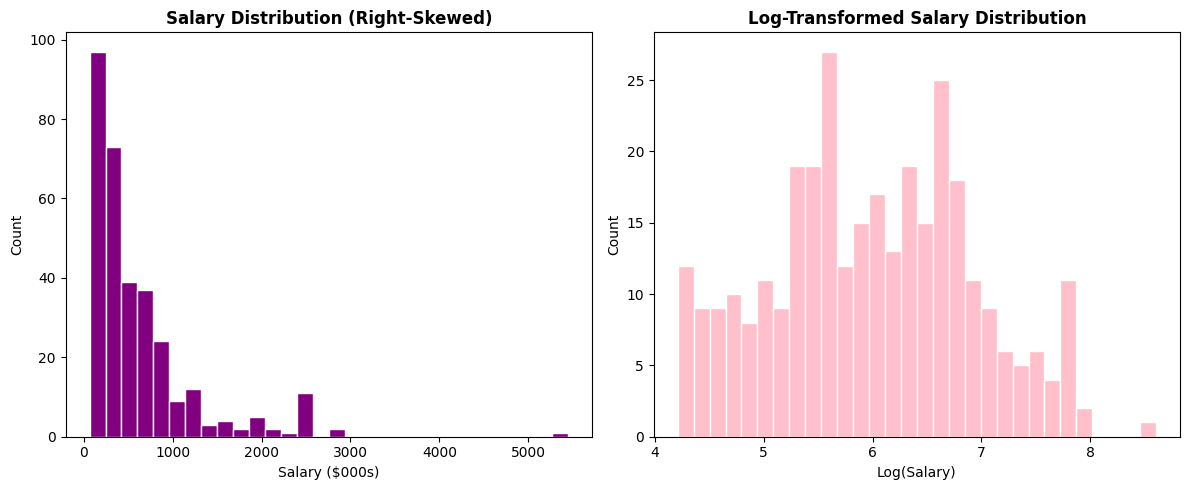

In [81]:
print("\n=== FINDING 1: Salary Distribution ===")
print(df['SALARY'].describe())
skewness = df['SALARY'].skew()
print(f"Skewness: {skewness:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['SALARY'], bins=30, color='purple', edgecolor='white')
axes[0].set_title('Salary Distribution (Right-Skewed)', fontweight='bold')
axes[0].set_xlabel('Salary ($000s)')
axes[0].set_ylabel('Count')
axes[1].hist(np.log(df['SALARY']), bins=30, color='pink', edgecolor='white')
axes[1].set_title('Log-Transformed Salary Distribution', fontweight='bold')
axes[1].set_xlabel('Log(Salary)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('fig1_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show() 
plt.close()

In [62]:
# FINDING 2: Season Performance Weakly Predicts Salary


=== FINDING 2: Season Performance vs Salary ===
  Home Runs: r=0.188, p=0.0007
  RBI: r=0.236, p=0.0000
  Runs: r=0.176, p=0.0015
  Hits: r=0.201, p=0.0003
  Walks: r=0.197, p=0.0004
  Batting Avg: r=0.132, p=0.0178


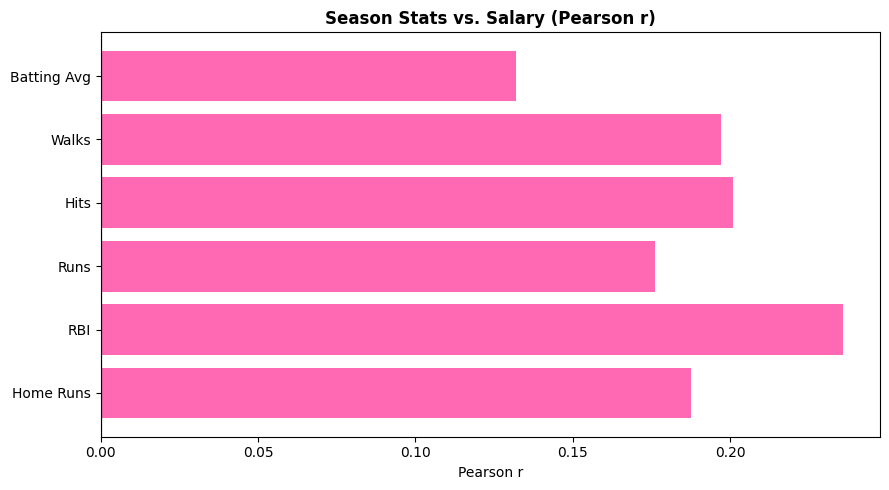

In [84]:
print("\n=== FINDING 2: Season Performance vs Salary ===")
perf_cols = ['NO_HOME', 'NO_RBI', 'NO_RUNS', 'NO_HITS', 'NO_BB', 'BAT_AVG']
labels = ['Home Runs', 'RBI', 'Runs', 'Hits', 'Walks', 'Batting Avg']
corr_vals = {}
for col, label in zip(perf_cols, labels):
    r, p = stats.pearsonr(df[col], df['SALARY'])
    corr_vals[label] = r
    print(f"  {label}: r={r:.3f}, p={p:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(corr_vals.keys()), list(corr_vals.values()), color='#FF69B4')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Season Stats vs. Salary (Pearson r)', fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig('fig2_season_perf_corr.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [64]:
# FINDING 3: Career Stats Predict Salary Much Better


=== FINDING 3: Career Stats vs Salary ===
  Career HR: r=0.408, p=0.0000
  Career RBI: r=0.451, p=0.0000
  Career Runs: r=0.450, p=0.0000
  Career Hits: r=0.447, p=0.0000
  Career BB: r=0.377, p=0.0000
  Career Avg: r=0.294, p=0.0000


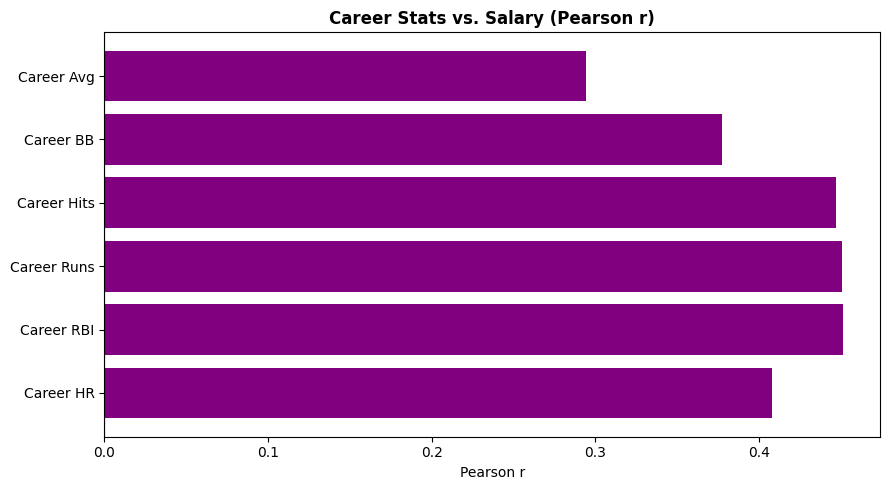

In [85]:
print("\n=== FINDING 3: Career Stats vs Salary ===")
career_cols = ['CR_HOME', 'CR_RBI', 'CR_RUNS', 'CR_HITS', 'CR_BB', 'CR_BAT_AVG']
career_labels = ['Career HR', 'Career RBI', 'Career Runs', 'Career Hits', 'Career BB', 'Career Avg']
career_corr = {}
for col, label in zip(career_cols, career_labels):
    r, p = stats.pearsonr(df[col], df['SALARY'])
    career_corr[label] = r
    print(f"  {label}: r={r:.3f}, p={p:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(career_corr.keys()), list(career_corr.values()), color='#800080')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Career Stats vs. Salary (Pearson r)', fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig('fig3_career_perf_corr.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [66]:
# FINDING 4: Years in Majors Strongly Predicts Salary


=== FINDING 4: Years in Majors vs Salary ===
  Slope: 46.93, Intercept: 253.75, r=0.361, p=0.000000


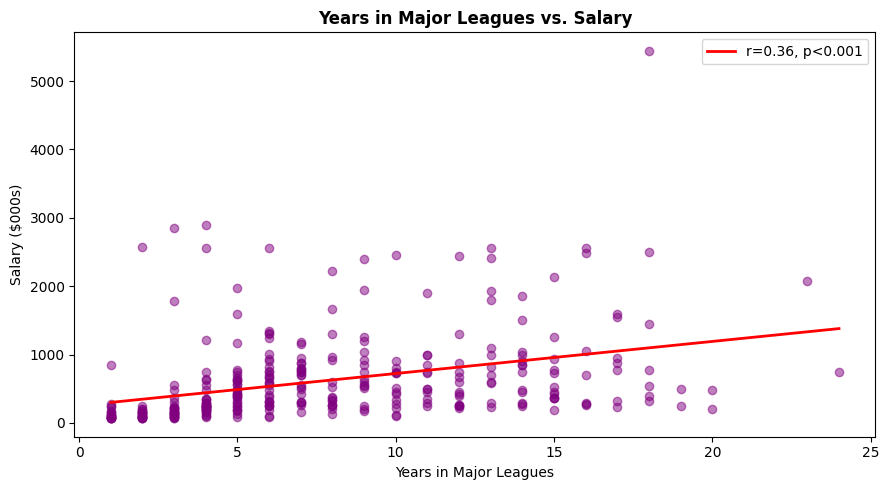

In [86]:
print("\n=== FINDING 4: Years in Majors vs Salary ===")
m, b, r, p, se = stats.linregress(df['YR_MAJOR'], df['SALARY'])
print(f"  Slope: {m:.2f}, Intercept: {b:.2f}, r={r:.3f}, p={p:.6f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['YR_MAJOR'], df['SALARY'], alpha=0.5, color='purple')
xline = np.linspace(df['YR_MAJOR'].min(), df['YR_MAJOR'].max(), 100)
ax.plot(xline, m*xline + b, color='red', linewidth=2, label=f'r={r:.2f}, p<0.001')
ax.set_title('Years in Major Leagues vs. Salary', fontweight='bold')
ax.set_xlabel('Years in Major Leagues')
ax.set_ylabel('Salary ($000s)')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_years_salary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [68]:
# FINDING 5: League Salary Difference (t-test)


=== FINDING 5: American vs National League Salary ===
  American mean: $643K  |  National mean: $580K
  t-statistic: 0.873, p-value: 0.384


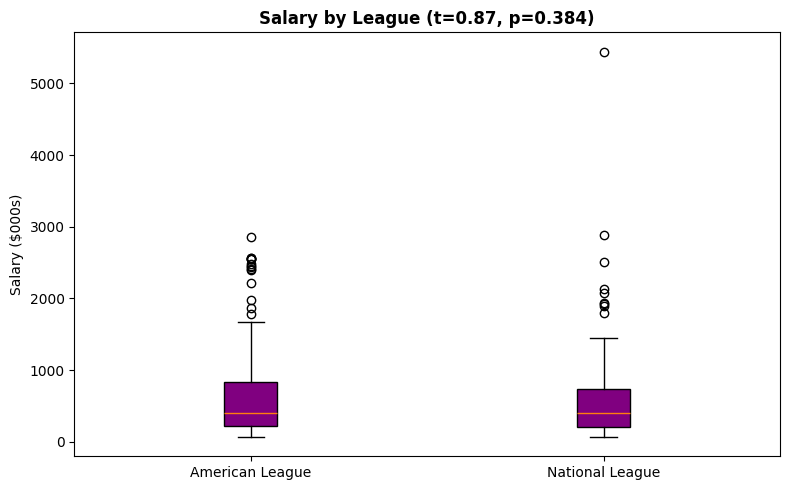

In [87]:
print("\n=== FINDING 5: American vs National League Salary ===")
am = df[df['LEAGUE']=='American']['SALARY']
nat = df[df['LEAGUE']=='National']['SALARY']
t, p = stats.ttest_ind(am, nat)
print(f"  American mean: ${am.mean():.0f}K  |  National mean: ${nat.mean():.0f}K")
print(f"  t-statistic: {t:.3f}, p-value: {p:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([am, nat], labels=['American League', 'National League'],
           patch_artist=True, boxprops=dict(facecolor='purple'))
ax.set_title(f'Salary by League (t={t:.2f}, p={p:.3f})', fontweight='bold')
ax.set_ylabel('Salary ($000s)')
plt.tight_layout()
plt.savefig('fig5_league_salary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [70]:
# FINDING 6: Position Determines Salary (ANOVA)


=== FINDING 6: Salary by Position ===
POSITION
1B    828.354839
LF    736.446400
RF    714.261154
3B    666.697813
CF    647.243462
DH    608.125000
2B    582.494839
C     554.222500
SS    478.777000
OF    442.005667
Name: SALARY, dtype: float64
  ANOVA: F=1.201, p=0.2943


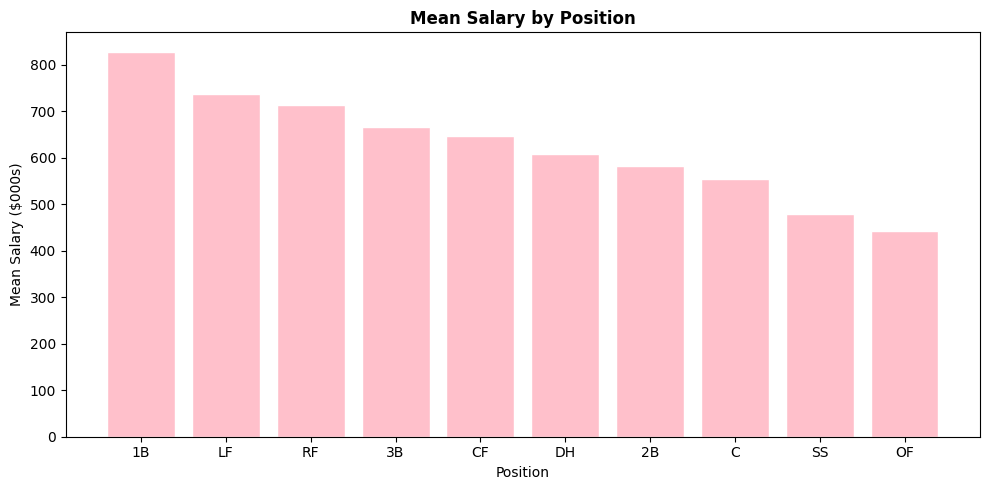

In [88]:
print("\n=== FINDING 6: Salary by Position ===")
main_pos = ['C','1B','2B','3B','SS','LF','CF','RF','OF','DH']
df_pos = df[df['POSITION'].isin(main_pos)]
pos_mean = df_pos.groupby('POSITION')['SALARY'].mean().sort_values(ascending=False)
print(pos_mean)
groups = [df_pos[df_pos['POSITION']==p]['SALARY'].values for p in main_pos]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"  ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pos_mean.index, pos_mean.values, color='pink', edgecolor='white')
ax.set_title('Mean Salary by Position', fontweight='bold')
ax.set_xlabel('Position')
ax.set_ylabel('Mean Salary ($000s)')
plt.tight_layout()
plt.savefig('fig6_position_salary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [72]:
# FINDING 7: Multiple Regression - Predicting Salary


=== FINDING 7: Multiple Regression ===
  R² = 0.226
  NO_HOME: -0.486
  NO_RBI: -0.058
  NO_RUNS: -1.254
  NO_HITS: 1.659
  NO_BB: 0.530
  YR_MAJOR: -23.392
  CR_HOME: 0.890
  CR_HITS: 0.402
  CR_RBI: 0.179


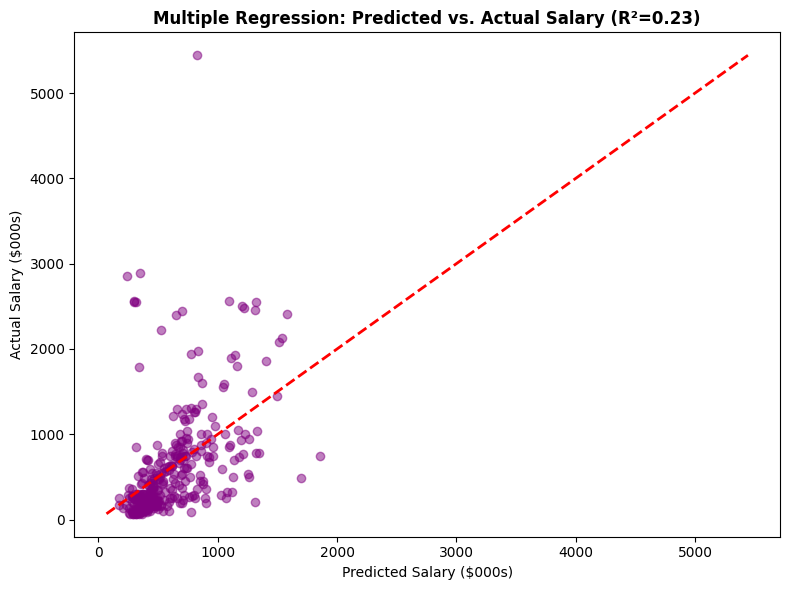

In [89]:
print("\n=== FINDING 7: Multiple Regression ===")
features = ['NO_HOME','NO_RBI','NO_RUNS','NO_HITS','NO_BB','YR_MAJOR','CR_HOME','CR_HITS','CR_RBI']
X = df[features]
y = df['SALARY']
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
r2 = r2_score(y, y_pred)
print(f"  R² = {r2:.3f}")
for f, c in zip(features, reg.coef_):
    print(f"  {f}: {c:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pred, y, alpha=0.5, color='purple')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
ax.set_title(f'Multiple Regression: Predicted vs. Actual Salary (R²={r2:.2f})', fontweight='bold')
ax.set_xlabel('Predicted Salary ($000s)')
ax.set_ylabel('Actual Salary ($000s)')
plt.tight_layout()
plt.savefig('fig7_regression.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [90]:
# FINDING 8: East Division Players Earn More

In [91]:
print("\n=== FINDING 8: East vs West Division ===")
east = df[df['DIVISION']=='East']['SALARY']
west = df[df['DIVISION']=='West']['SALARY']
t_ew, p_ew = stats.ttest_ind(east, west)
print(f"  East mean: ${east.mean():.0f}K  |  West mean: ${west.mean():.0f}K")
print(f"  t={t_ew:.3f}, p={p_ew:.3f}")


=== FINDING 8: East vs West Division ===
  East mean: $681K  |  West mean: $551K
  t=1.813, p=0.071


In [92]:
# FINDING 9: Veterans (10+ yrs) Earn Dramatically More


=== FINDING 9: Veterans vs Non-Veterans ===
  Veteran mean: $893K (n=90)  |  Non-Vet mean: $506K (n=232)
  t=4.991, p=0.00000099


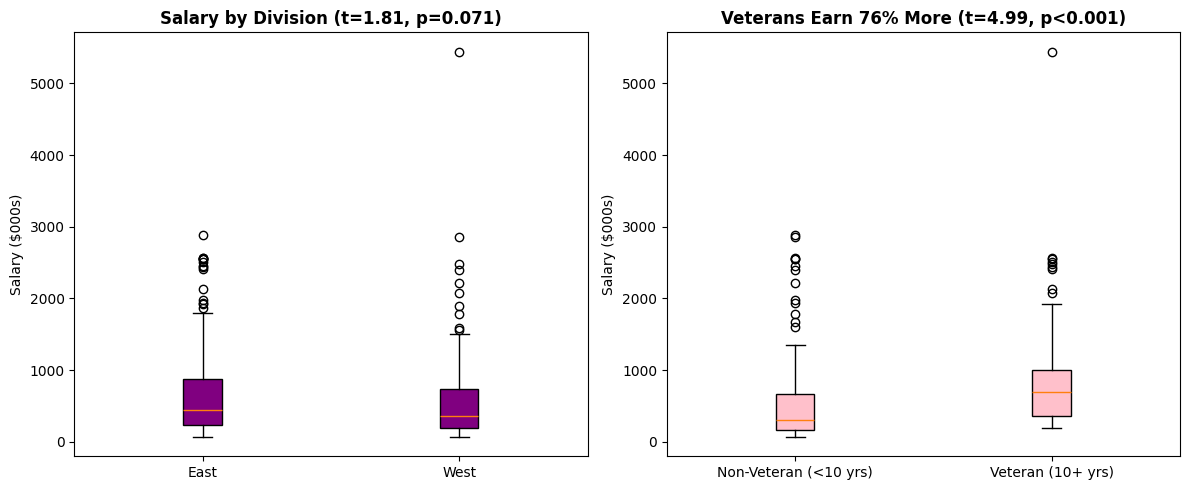

In [93]:
print("\n=== FINDING 9: Veterans vs Non-Veterans ===")
vet = df[df['VETERAN']]['SALARY']
non_vet = df[~df['VETERAN']]['SALARY']
t_vet, p_vet = stats.ttest_ind(vet, non_vet)
print(f"  Veteran mean: ${vet.mean():.0f}K (n={len(vet)})  |  Non-Vet mean: ${non_vet.mean():.0f}K (n={len(non_vet)})")
print(f"  t={t_vet:.3f}, p={p_vet:.8f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([east, west], labels=['East', 'West'],
               patch_artist=True, boxprops=dict(facecolor='purple'))
axes[0].set_title(f'Salary by Division (t={t_ew:.2f}, p={p_ew:.3f})', fontweight='bold')
axes[0].set_ylabel('Salary ($000s)')
axes[1].boxplot([non_vet, vet], labels=['Non-Veteran (<10 yrs)', 'Veteran (10+ yrs)'],
               patch_artist=True, boxprops=dict(facecolor='pink'))
axes[1].set_title(f'Veterans Earn 76% More (t={t_vet:.2f}, p<0.001)', fontweight='bold')
axes[1].set_ylabel('Salary ($000s)')
plt.tight_layout()
plt.savefig('fig8_9_division_veteran.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


In [78]:
# FINDING 10: Team Spending — Baltimore Leads the Pack


=== FINDING 10: Team Salary Rankings ===
TEAM
Baltimore      1023.266667
LosAngeles      876.642857
Boston          810.681818
Minneapolis     796.000000
NewYork         765.750937
Oakland         757.916667
Milwaukee       664.394737
Detroit         659.817500
Cincinnati      639.180833
StLouis         621.970000
Name: SALARY, dtype: float64


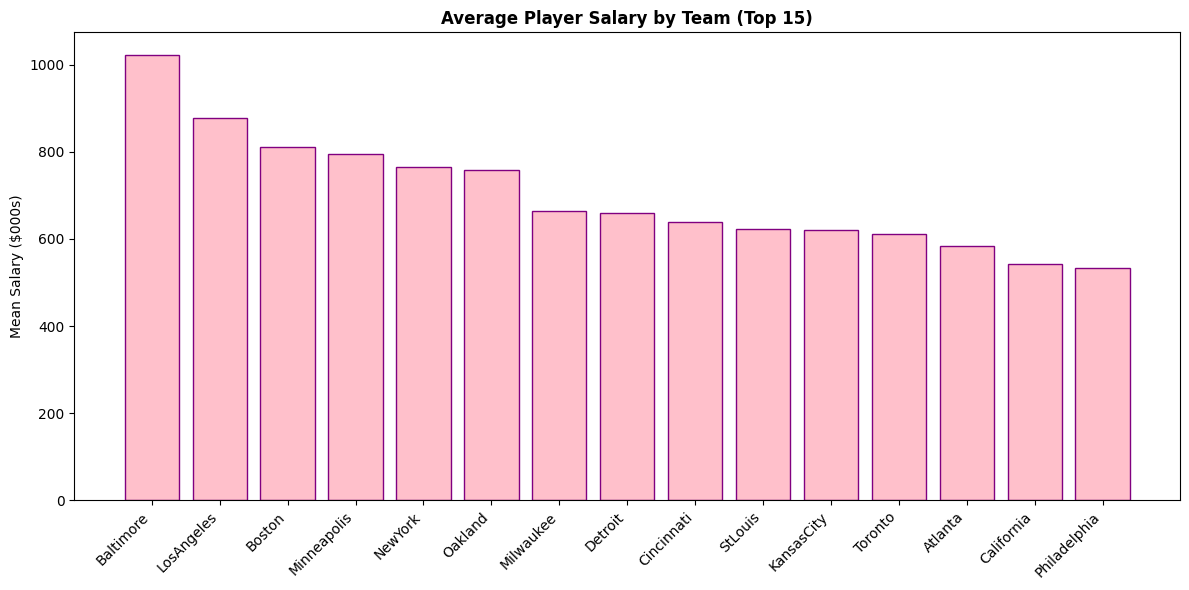


=== End ===


In [94]:
print("\n=== FINDING 10: Team Salary Rankings ===")
team_salary = df.groupby('TEAM')['SALARY'].mean().sort_values(ascending=False)
print(team_salary.head(10))

fig, ax = plt.subplots(figsize=(12, 6))
top15 = team_salary.head(15)
ax.bar(range(len(top15)), top15.values, color='pink', edgecolor='purple')
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=45, ha='right')
ax.set_title('Average Player Salary by Team (Top 15)', fontweight='bold')
ax.set_ylabel('Mean Salary ($000s)')
plt.tight_layout()
plt.savefig('fig10_team_salary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("\n=== End ===")